# Check Freeze TabR

- fokus: bandingkan beberapa `freeze_context_epoch` pada split yang sama
- output per run: metrik internal/external + log epoch + ringkasan per freeze


## Notebook ini untuk audit efek freeze\n
Menjalankan beberapa nilai `freeze_context_epoch` pada data/split yang sama agar perubahan performa bisa dibandingkan langsung.


In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train_freeze_check'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_EPOCHS = [0, 6, 10, 15, 20]
M_NEIGHBORS = 4
EARLY_STOPPING_PATIENCE = 10

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_epochs': FREEZE_EPOCHS, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train_freeze_check
{'lr': 0.0003, 'freeze_epochs': [0, 6, 10, 15, 20], 'm': 4, 'patience': 10}


In [4]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_CONTEXT_EPOCH = 6
M_NEIGHBORS = 4
EARLY_STOPPING_PATIENCE = 10

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_context_epoch': FREEZE_CONTEXT_EPOCH, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0003, 'freeze_context_epoch': 6, 'm': 4, 'patience': 10}


In [5]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [6]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [7]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [8]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['event_id'].isin(external_event_ids)].copy()

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 40
External rows: (906, 407)
Train rows: (56750, 407)
{'anxiety_tinggi': 20, 'anxiety_rendah': 20}
label
anxiety_rendah    15
anxiety_tinggi    14
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               14               7
before               6              13


In [9]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [10]:
train_events = event_table[~event_table['event_id'].isin(external_event_ids)].copy()
train_event_ids, val_event_ids = train_test_split(
    train_events['event_id'],
    test_size=0.2,
    stratify=train_events['target'],
    random_state=RANDOM_SEED,
)

train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_tr = df_train_all[df_train_all['event_id'].isin(train_event_ids)].copy()
df_val = df_train_all[df_train_all['event_id'].isin(val_event_ids)].copy()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

print('train events:', len(train_event_ids))
print('val events:', len(val_event_ids))
print(X_train.shape, X_val.shape, X_ext.shape)


train events: 2178
val events: 545
torch.Size([44977, 392]) torch.Size([11773, 392]) torch.Size([906, 392])


In [11]:
def train_tabr_from_dataframe(out_dir: Path, freeze_context_epoch: int):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=freeze_context_epoch,
        m=M_NEIGHBORS,
        lr=LR,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(out_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(out_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = LitTabR.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(out_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'lr': LR,
        'freeze_context_epoch': freeze_context_epoch,
        'm_neighbors': M_NEIGHBORS,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(out_dir / 'run_config.csv', index=False)

    print(f'INTERNAL | freeze={freeze_context_epoch}')
    model.eval()
    model.set_context(ctx_train_X, ctx_train_y)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print(f'EXTERNAL | freeze={freeze_context_epoch}')
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}


In [12]:
freeze_results = []
trained_runs = {}

for freeze_epoch in FREEZE_EPOCHS:
    out_dir = get_next_train_dir(TRAIN_ROOT)
    print(out_dir)
    model, results = train_tabr_from_dataframe(out_dir, freeze_context_epoch=freeze_epoch)
    trained_runs[freeze_epoch] = {'out_dir': out_dir, 'model': model, 'results': results}
    freeze_results.append({
        'freeze_context_epoch': freeze_epoch,
        'out_dir': str(out_dir),
        'internal_accuracy': results['internal']['accuracy'],
        'external_accuracy': results['external']['accuracy'],
        'internal_macro_f1': results['internal']['report']['macro avg']['f1-score'],
        'external_macro_f1': results['external']['report']['macro avg']['f1-score'],
        'internal_weighted_f1': results['internal']['report']['weighted avg']['f1-score'],
        'external_weighted_f1': results['external']['report']['weighted avg']['f1-score'],
    })

freeze_summary = pd.DataFrame(freeze_results).sort_values('freeze_context_epoch').reset_index(drop=True)
freeze_summary


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t16


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t16 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training context prepared for validation & FAISS built


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL | freeze=20
EXTERNAL | freeze=20


,freeze_context_epoch,out_dir,internal_accuracy,external_accuracy,internal_macro_f1,external_macro_f1,internal_weighted_f1,external_weighted_f1
0,0,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.607747,0.584989,0.398206,0.378764,0.484562,0.441185
1,6,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605708,0.584989,0.392457,0.373978,0.479989,0.437362
2,10,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.604774,0.587196,0.394482,0.377308,0.481260,0.440354
3,15,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605538,0.587196,0.389730,0.369958,0.477983,0.434476
4,20,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.606642,0.582781,0.403894,0.377824,0.488437,0.440100


In [13]:
freeze_summary.to_csv(TRAIN_ROOT / 'freeze_summary.csv', index=False)
freeze_summary


,freeze_context_epoch,out_dir,internal_accuracy,external_accuracy,internal_macro_f1,external_macro_f1,internal_weighted_f1,external_weighted_f1
0,0,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.607747,0.584989,0.398206,0.378764,0.484562,0.441185
1,6,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605708,0.584989,0.392457,0.373978,0.479989,0.437362
2,10,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.604774,0.587196,0.394482,0.377308,0.481260,0.440354
3,15,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605538,0.587196,0.389730,0.369958,0.477983,0.434476
4,20,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.606642,0.582781,0.403894,0.377824,0.488437,0.440100


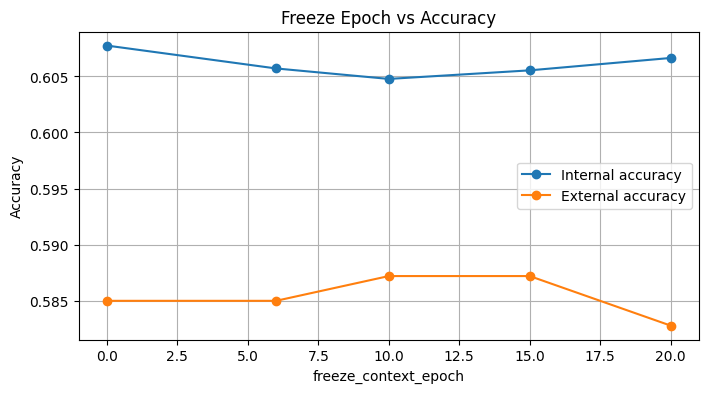

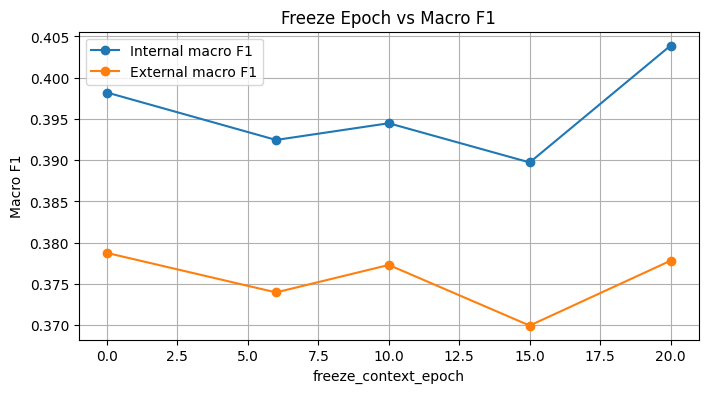

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(freeze_summary['freeze_context_epoch'], freeze_summary['internal_accuracy'], marker='o', label='Internal accuracy')
plt.plot(freeze_summary['freeze_context_epoch'], freeze_summary['external_accuracy'], marker='o', label='External accuracy')
plt.xlabel('freeze_context_epoch')
plt.ylabel('Accuracy')
plt.title('Freeze Epoch vs Accuracy')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(freeze_summary['freeze_context_epoch'], freeze_summary['internal_macro_f1'], marker='o', label='Internal macro F1')
plt.plot(freeze_summary['freeze_context_epoch'], freeze_summary['external_macro_f1'], marker='o', label='External macro F1')
plt.xlabel('freeze_context_epoch')
plt.ylabel('Macro F1')
plt.title('Freeze Epoch vs Macro F1')
plt.grid(True)
plt.legend()
plt.show()


In [15]:
freeze_summary.sort_values(['external_macro_f1', 'external_accuracy'], ascending=False)


,freeze_context_epoch,out_dir,internal_accuracy,external_accuracy,internal_macro_f1,external_macro_f1,internal_weighted_f1,external_weighted_f1
0,0,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.607747,0.584989,0.398206,0.378764,0.484562,0.441185
4,20,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.606642,0.582781,0.403894,0.377824,0.488437,0.440100
2,10,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.604774,0.587196,0.394482,0.377308,0.481260,0.440354
1,6,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605708,0.584989,0.392457,0.373978,0.479989,0.437362
3,15,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.605538,0.587196,0.389730,0.369958,0.477983,0.434476


best_freeze = 0
best_out_dir = /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t16


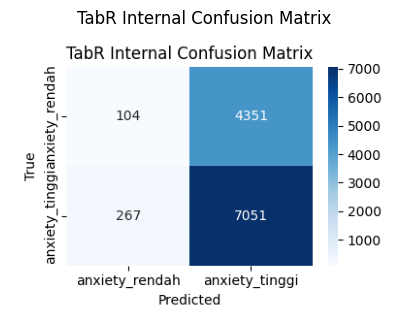

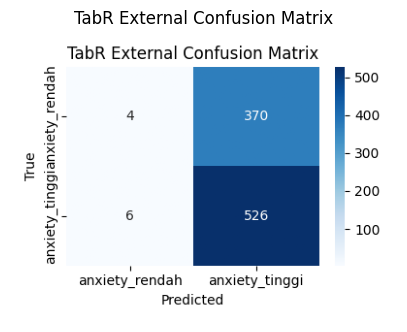


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score       support
0              0.280323  0.023345  0.043100   4455.000000
1              0.618400  0.963515  0.753312   7318.000000
accuracy       0.607747  0.607747  0.607747      0.607747
macro avg      0.449362  0.493430  0.398206  11773.000000
weighted avg   0.490469  0.607747  0.484562  11773.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.400000  0.010695  0.020833  374.000000
1              0.587054  0.988722  0.736695  532.000000
accuracy       0.584989  0.584989  0.584989    0.584989
macro avg      0.493527  0.499708  0.378764  906.000000
weighted avg   0.509837  0.584989  0.441185  906.000000


In [16]:
best_freeze = int(freeze_summary.sort_values(['external_macro_f1', 'external_accuracy'], ascending=False).iloc[0]['freeze_context_epoch'])
best_out_dir = Path(trained_runs[best_freeze]['out_dir'])
print('best_freeze =', best_freeze)
print('best_out_dir =', best_out_dir)
visualize_results(best_out_dir)


In [17]:
metrics_files = sorted(TRAIN_ROOT.glob('t*/tabr_logs/version_*/metrics.csv'))
[(str(p.parent.parent), str(p)) for p in metrics_files]


[('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t1/tabr_logs',
  '/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t1/tabr_logs/version_0/metrics.csv'),
 ('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t10/tabr_logs',
  '/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t10/tabr_logs/version_0/metrics.csv'),
 ('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t11/tabr_logs',
  '/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t11/tabr_logs/version_0/metrics.csv'),
 ('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t12/tabr_logs',
  '/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t12/tabr_logs/version_0/metrics.csv'),
 ('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t13/tabr_logs',
  '/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t13/tabr_logs/ve

=== freeze=0 ===
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t16/tabr_logs/version_0/metrics.csv


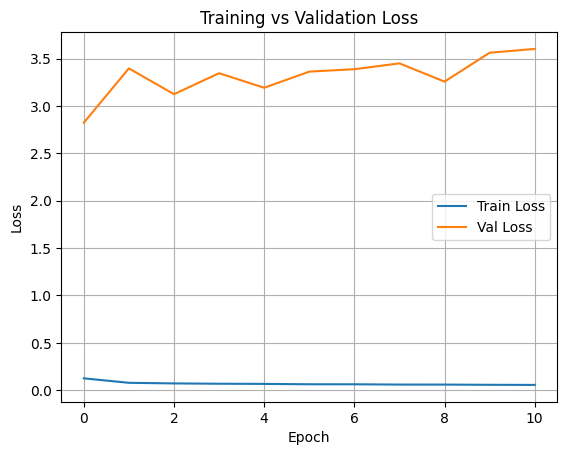

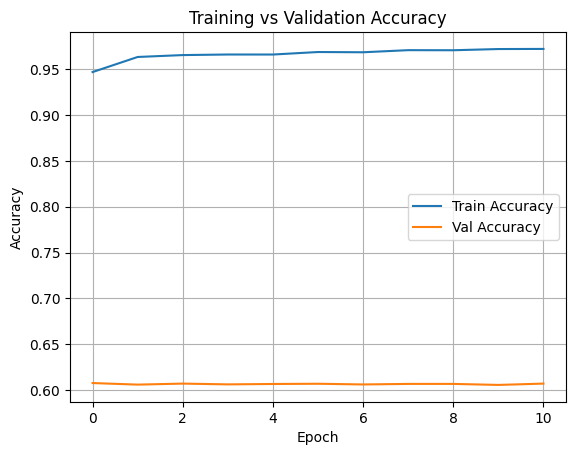

=== freeze=6 ===
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t17/tabr_logs/version_0/metrics.csv


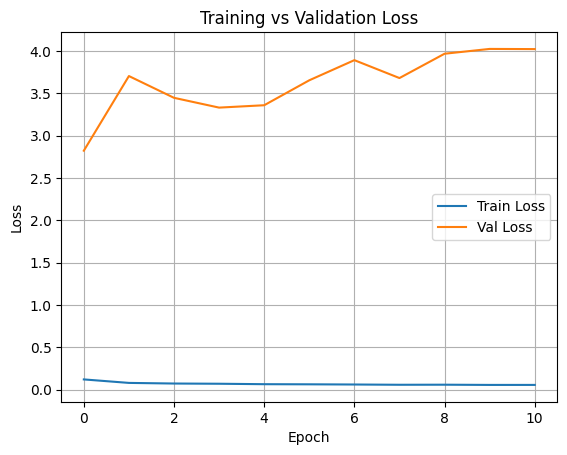

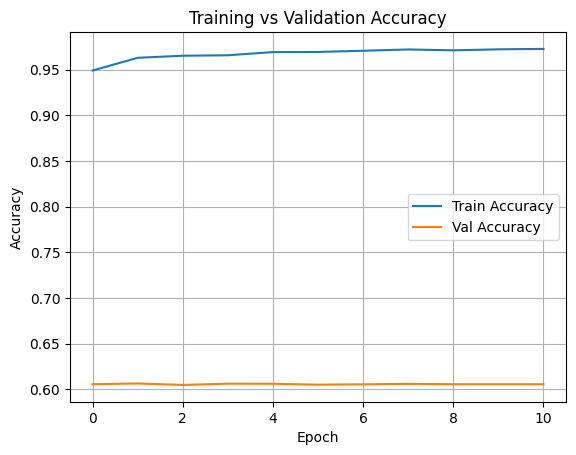

=== freeze=10 ===
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t18/tabr_logs/version_0/metrics.csv


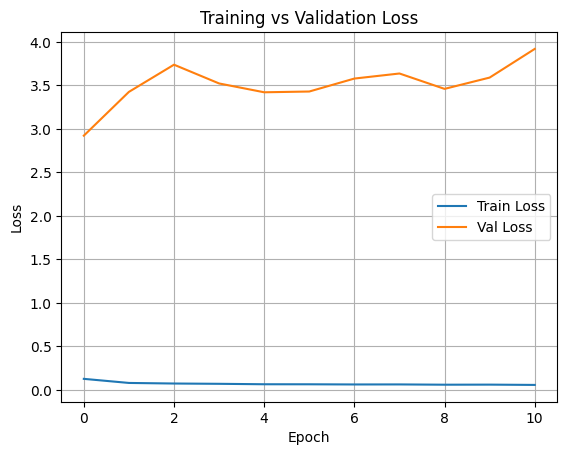

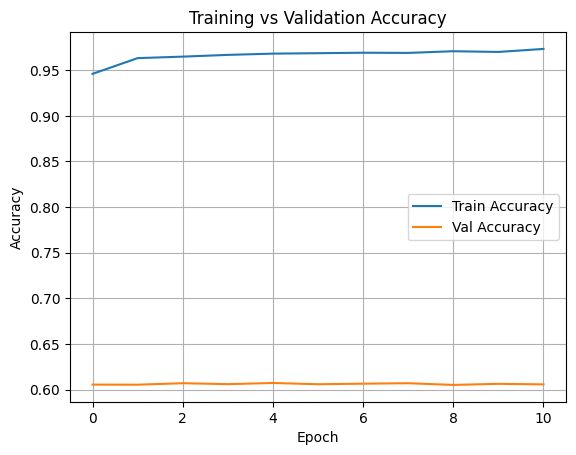

=== freeze=15 ===
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t19/tabr_logs/version_0/metrics.csv


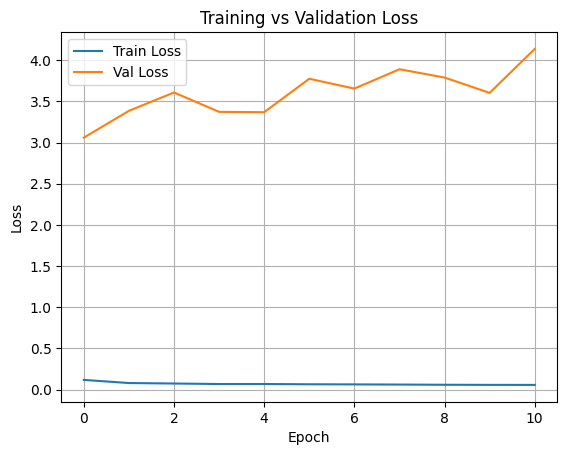

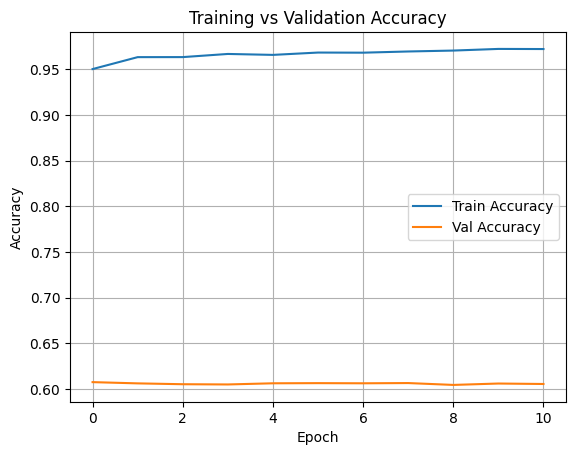

=== freeze=20 ===
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t20/tabr_logs/version_0/metrics.csv


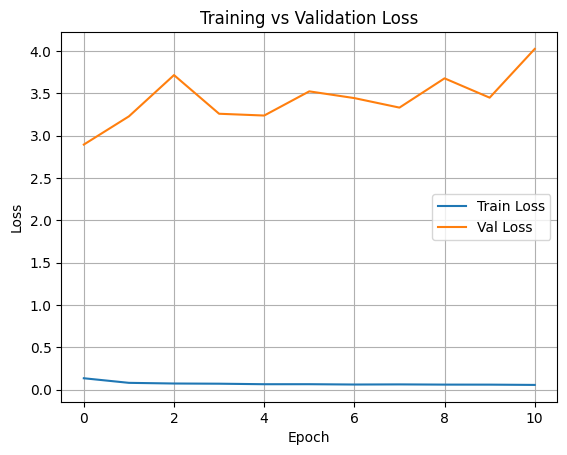

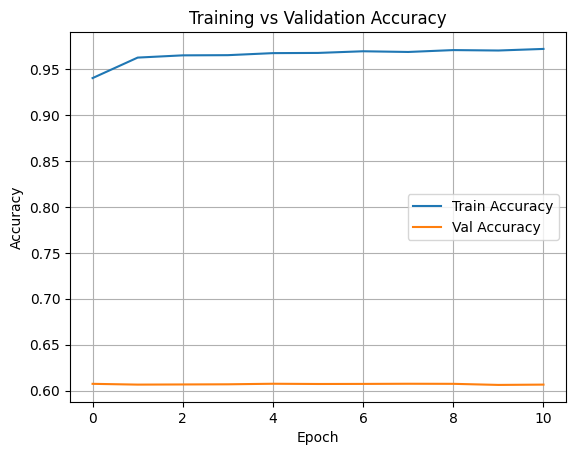

In [18]:
for freeze_epoch, payload in trained_runs.items():
    out_dir = Path(payload['out_dir'])
    metrics_csv = sorted((out_dir / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
    print(f'=== freeze={freeze_epoch} ===')
    print(metrics_csv)
    plot_lightning_metrics(metrics_csv)
